In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the MNIST dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Check the size of the data

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

# Reshape the images

In [7]:
#MNIST is grayscale. Conv2D expects image data in this general format: (number of images, height, width, channels)
# so convert to reshapes train and test set.
# RGB image: 3 channels — Red, Green, Blue
# RGBA image: 4 channels — Red, Green, Blue, Alpha (transparency)
# Grayscale image: 1 channel
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [8]:
x_train.dtype

dtype('uint8')

# Convert the data to float. the original pixel values are integers. convert them to decimal numbers. This is more suitable for neural-network calculations

In [9]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [10]:
x_train.dtype

dtype('float32')

# Normalize the pixel values Originally, pixel values range from 0 to 255. We divide by 255 so they become 0 to 1. so this is normalization. the neural network learn more efficiently

In [11]:
x_train /= 255
x_test /= 255

# Sequential - Allows us to build the network layer by layer.
# Conv2D - Looks for important patterns in images(edges, lines, curves,corners).
# MaxPooling2D - Reduces the size of the image/features while keeping important information.
# Flatten - Converts a 2D feature map into a single long list of numbers. 
# Dense - A normal neural-network layer. 
# Dropout -Randomly turns off some neurons during training to reduce overfitting.

In [12]:
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
#Create the model
model = Sequential()
# Add the Convolution layer - creates 28 filters.
# kernel_size=(3,3) - each filter looks at a small 3 × 3 matrix.
# Max Pooling - the feature maps smaller. reduce the amount of data and keep important features
# Flatten the data - height × width × features 
#[ [1,2],    to [1,2,3,4]
#  [3,4] ]
# Dense layer -  128 neurons with fully connected layer. ReLU - negative number → 0 and positive number → keep it and network learn complex patterns.
# Examples -5 → 0
#-2 → 0
# 3 → 3
# 8 → 8
# Dropout - approximately 20% of neurons are randomly ignored during training - To prevent overfitting
# Output layer - Why 10 neurons - 10 class only output. softmax function converts the outputs into probabilities. The highest probability is output

model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

C:\Anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the model & Train the model

In [13]:
#https://keras.io/api/optimizers/
#Before training, we need to tell the model how it should learn. Adam controls how the model changes its weights while learning.
# loss - How wrong was the model?
# Accuracy - TensorFlow to show how many predictions are correct.
# fit - where the model actually learns.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9357 - loss: 0.2104
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9732 - loss: 0.0890
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9800 - loss: 0.0619
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9848 - loss: 0.0455
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9882 - loss: 0.0363
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9891 - loss: 0.0314
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9915 - loss: 0.0249
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9918 - loss: 0.0245
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9934 - loss: 0.0191
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9941 - loss: 0.0170


# Test the model & we give the model images it has not trained on.

In [14]:
#x_train → model learns 
#x_test → check how well it learned
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9835 - loss: 0.0687


[0.06867476552724838, 0.9835000038146973]

# Confustion matrix

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


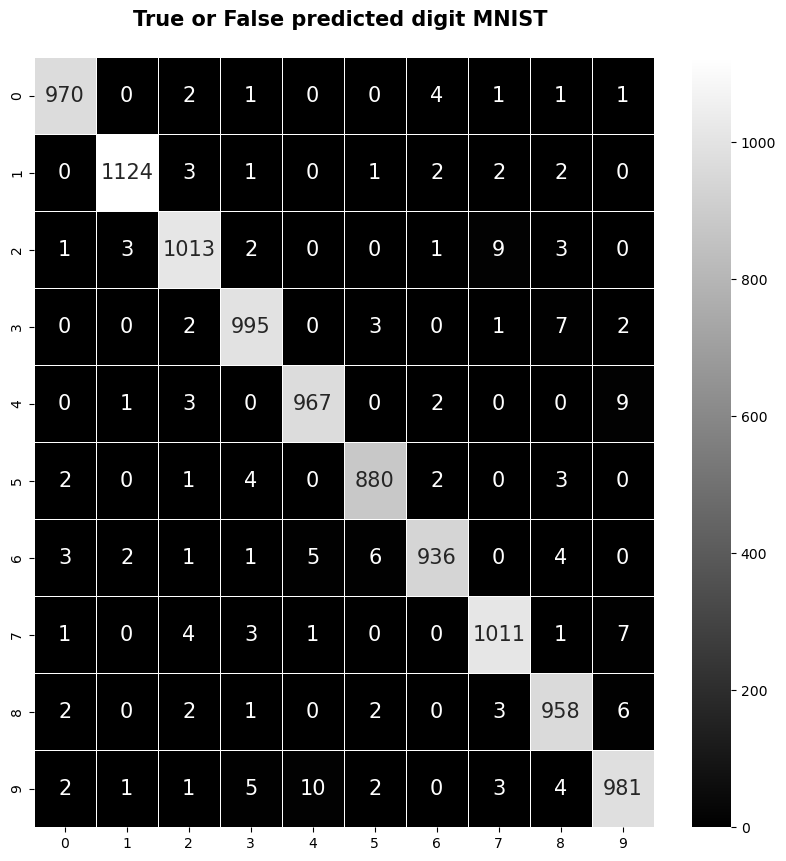

In [15]:
y_test= to_categorical(y_test, num_classes = 10)

Y_pred = model.predict(x_test, batch_size=100)
Y_predict = np.argmax(Y_pred, axis=1)
Y_test_eval = np.argmax(y_test, axis=1)
con_mat = confusion_matrix(Y_test_eval, Y_predict)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot =True, annot_kws={'size':15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title('True or False predicted digit MNIST \n', fontweight ='bold', fontsize =15)
plt.show()

# Show the Classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(Y_test_eval,Y_predict))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Choose one test image & Display the image & Store the image  & Ask the model to predict the digit & Get the highest probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2


Text(0.5, 0, 'Actual:Two,Pred:Two')

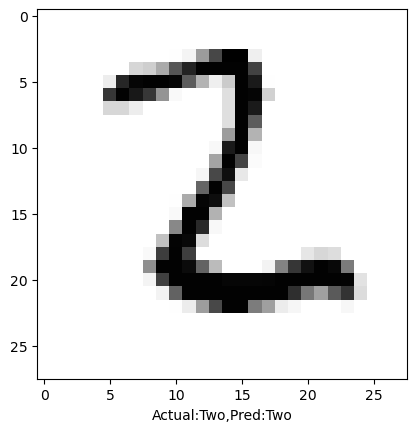

In [17]:

image_index = 6800
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

plt.imshow(x_test[image_index].reshape(28, 28,1),cmap='Greys')
predict = x_test[image_index].reshape(28,28,1)
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())
plt.xlabel("Actual:{},Pred:{}".format(col_names[Y_test_eval[image_index]],col_names[pred.argmax()]))